In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

# смотрим точные названия файлов в папке
print(os.listdir())

# вкладка "Данные об аудитории"
audience = pd.read_csv('Данные для тестового задания - Данные об аудитории.csv')
audience['date'] = pd.to_datetime(audience['date'])

print(audience.shape)
audience.head()

['.ipynb_checkpoints', '500_Person_Gender_Height_Weight_Index.csv', 'coffee_sales_data.csv', 'compare_df.csv', 'CSE_student_performances.csv', 'data.csv', 'DID_test.csv', 'energy.csv', 'first_10_rows.xlsx', 'flights_2008.csv.bz2', 'guild_data.csv', 'heart_disease_uci.csv', 'HW1 L6 Переменные в Python.ipynb', 'HW10 L5 Объединение массивов.ipynb', 'HW11 L3 Пример с матрицами.ipynb', 'HW12 L8 Очистка данных.ipynb', 'HW13 L12 Функция reset_index.ipynb', 'HW14 L15 Проект Анализ данных обзоров вин.ipynb', 'HW15 L17 Настройка графика.ipynb', 'HW16 L19 Анализ датасета Iris с использованием Matplotlib в Python.ipynb', 'HW17 L21 Разбор кейса.ipynb', 'HW18 L22 mini_project_Yakhiya_Ademi.ipynb', 'HW19 L25 Парсинг (3 часть).ipynb', 'HW2 L10 Boolean.ipynb', 'HW20 L26 API.ipynb', 'HW21 L39 Недообучение и Переобучение модели', 'HW21 L39 Недообучение и Переобучение модели.ipynb', 'HW22 L41 Классификация (Часть 2).ipynb', 'HW23 L42 Mini project ML.ipynb', 'HW24 L2 Что такое функция Math 1 (1).ipynb', 'H

,date,user_id,view_adverts
0,2023-11-11,8c020470-8461-11ed-83d0-552e8cc749d6,13
1,2023-11-18,5875f070-7b92-11ee-a6fb-8b298e83f4f7,14
2,2023-11-29,3c2d27c0-4fd6-11eb-b89f-2ffb31b67dd6,21
3,2023-11-29,234a96d0-ad16-11ed-a2e6-793ddfeeba1f,23
4,2023-11-29,4d07c180-644f-11eb-879c-b7c02edf4f37,12


In [2]:
# проверка данных: период, пропуски, дубликаты
print('Период:', audience['date'].min(), '-', audience['date'].max())
print('Пропуски:\n', audience.isna().sum())
print('Дубликатов:', audience.duplicated().sum())

Период: 2023-11-01 00:00:00 - 2023-11-30 00:00:00
Пропуски:
 date            0
user_id         0
view_adverts    0
dtype: int64
Дубликатов: 0


In [3]:
#1 MAU - количество уникальных пользователей за месяц
mau = audience['user_id'].nunique()
print('MAU:', mau)

MAU: 7639


In [6]:
#2 DAU - уникальные пользователи за каждый день, потом среднее за месяц
dau = audience.groupby('date')['user_id'].nunique()
print(dau)
print('Средний DAU:', round(dau.mean()))

date
2023-11-01    623
2023-11-02    649
2023-11-03    573
2023-11-04    343
2023-11-05    350
2023-11-06    660
2023-11-07    629
2023-11-08    600
2023-11-09    661
2023-11-10    583
2023-11-11    354
2023-11-12    377
2023-11-13    646
2023-11-14    687
2023-11-15    690
2023-11-16    639
2023-11-17    585
2023-11-18    412
2023-11-19    378
2023-11-20    711
2023-11-21    651
2023-11-22    608
2023-11-23    632
2023-11-24    595
2023-11-25    366
2023-11-26    372
2023-11-27    589
2023-11-28    610
2023-11-29    621
2023-11-30    620
Name: user_id, dtype: int64
Средний DAU: 560


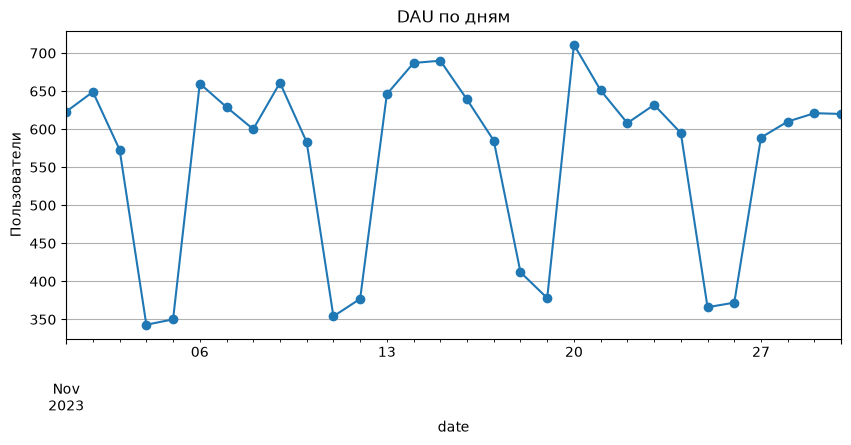

In [5]:
# график DAU по дням (дополнительно)
dau.plot(marker='o', figsize=(10, 4))
plt.title('DAU по дням')
plt.ylabel('Пользователи')
plt.grid(True)
plt.show()

In [7]:
#3Retention первого дня для пришедших 1 ноября
# день первого визита каждого пользователя
first_day = audience.groupby('user_id')['date'].min()

# пользователи, пришедшие 1 ноября
cohort = first_day[first_day == '2023-11-01'].index

# кто из них вернулся 2 ноября
users_nov2 = set(audience.loc[audience['date'] == '2023-11-02', 'user_id'])
returned = [u for u in cohort if u in users_nov2]

retention_d1 = len(returned) / len(cohort)
print('Пришли 1 ноября:', len(cohort))
print('Вернулись 2 ноября:', len(returned))
print(f'Retention 1 дня: {retention_d1:.1%}')

Пришли 1 ноября: 623
Вернулись 2 ноября: 166
Retention 1 дня: 26.6%


**Ответ:** у обоих продуктов на 1-й день удержание одинаковое (~72%), то есть первое впечатление и онбординг похожи. Дальше кривые расходятся:
- Синий продукт выходит на «плато» около 38-40% начиная с 4-5 дня у продукта есть ядро постоянных пользователей, он даёт людям ценность (признак product-market fit).
- Красный продукт теряет пользователей до 0% к 5-му дню никто не остаётся, продукт не удерживает аудиторию. Пользователи пробуют его, но не находят причин возвращаться.
Вывод: синий продукт здоровый, красному нужно разбираться с ценностью продукта после первого дня.

In [8]:
#5 сколько объявлений каждый пользователь посмотрел за весь ноябрь
views_per_user = audience.groupby('user_id')['view_adverts'].sum()

# конверсия = доля пользователей, посмотревших хотя бы одно объявление
conversion = (views_per_user > 0).mean()
print(f'Конверсия в просмотр: {conversion:.1%}')

Конверсия в просмотр: 46.3%


In [9]:
#6 Среднее количество просмотров на пользователя
avg_views = views_per_user.mean()
print('Среднее количество просмотров на пользователя:', round(avg_views, 1))

Среднее количество просмотров на пользователя: 2.9


In [10]:
#7 NPS
total = 2000
promoters = 1200
detractors = 500

nps = (promoters / total - detractors / total) * 100
print(f'NPS = {nps:.0f}%')

NPS = 35%


In [15]:
#8 ABC tests
import glob

print(glob.glob('*.csv'))   # все CSV в папке с ноутбуком

ab_file = [f for f in glob.glob('*.csv') if 'АБ' in f][0]
listers_file = [f for f in glob.glob('*.csv') if 'Листер' in f][0]
print(ab_file, '|', listers_file)

ab = pd.read_csv(ab_file)
listers = pd.read_csv(listers_file)


['500_Person_Gender_Height_Weight_Index.csv', 'coffee_sales_data.csv', 'compare_df.csv', 'CSE_student_performances.csv', 'data.csv', 'DID_test.csv', 'energy.csv', 'guild_data.csv', 'heart_disease_uci.csv', 'listings.csv', 'normality_test.csv', 'payers (1).csv', 'price_sample.csv', 'weather.csv.gz.csv', 'Данные для тестового задания - Данные АБ тестов.csv', 'Данные для тестового задания - Данные об аудитории.csv', 'Данные для тестового задания - Листеры.csv', 'ДЗ_Pandas.csv', 'Таблица для ДЗ (1).csv']
Данные для тестового задания - Данные АБ тестов.csv | Данные для тестового задания - Листеры.csv


In [16]:
for exp, data in ab.groupby('experiment_num'):
    print(f'\n=== Эксперимент {exp} ===')

    summary = data.groupby('experiment_group')['revenue'].agg(['count', 'sum', 'mean', 'median'])
    summary.columns = ['пользователей', 'выручка', 'ARPU', 'медиана']
    print(summary.round(1))

    control = data.loc[data['experiment_group'] == 'control', 'revenue']
    test = data.loc[data['experiment_group'] == 'test', 'revenue']

    t_p = stats.ttest_ind(test, control, equal_var=False).pvalue
    mw_p = stats.mannwhitneyu(test, control).pvalue
    print(f't-тест p-value: {t_p:.4f}')
    print(f'Манн-Уитни p-value: {mw_p:.4f}')


=== Эксперимент 1 ===
                  пользователей  выручка   ARPU  медиана
experiment_group                                        
control                     465   335944  722.5    104.0
test                        480   319555  665.7    104.0
t-тест p-value: 0.6890
Манн-Уитни p-value: 0.7960

=== Эксперимент 2 ===
                  пользователей  выручка   ARPU  медиана
experiment_group                                        
control                     465   327664  704.7     74.0
test                        480   159806  332.9     52.0
t-тест p-value: 0.0011
Манн-Уитни p-value: 0.0085

=== Эксперимент 3 ===
                  пользователей  выручка   ARPU  медиана
experiment_group                                        
control                     465   308391  663.2      4.0
test                        480   479361  998.7    156.0
t-тест p-value: 0.0603
Манн-Уитни p-value: 0.0010


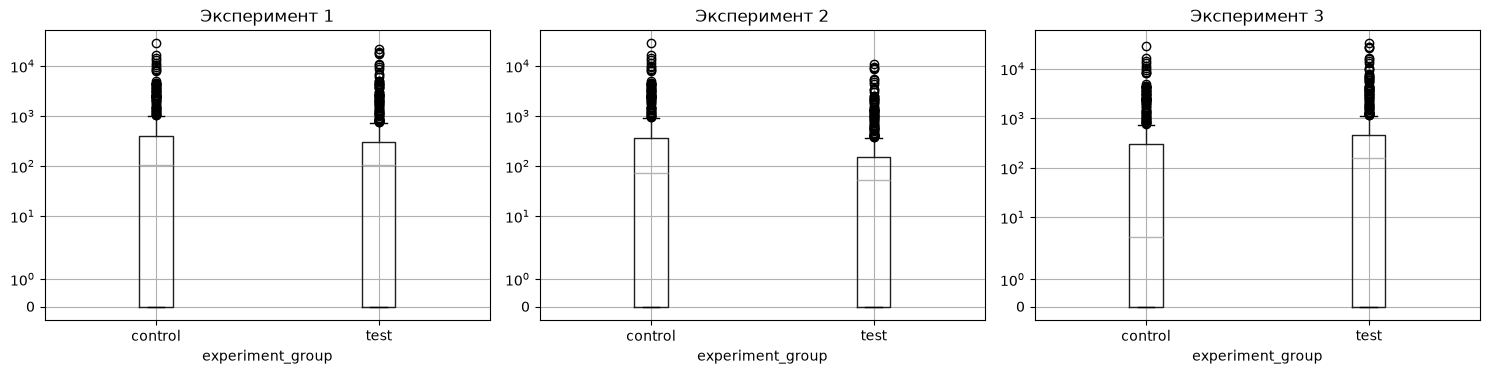

In [17]:
# boxplot выручки (лог-шкала, т.к. есть очень большие платежи)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (exp, data) in zip(axes, ab.groupby('experiment_num')):
    data.boxplot(column='revenue', by='experiment_group', ax=ax)
    ax.set_yscale('symlog')
    ax.set_title(f'Эксперимент {exp}')
plt.suptitle('')
plt.tight_layout()
plt.show()

**Эксперимент 1:** p-value ≈ 0.69, разницы нет. ARPU в тесте даже чуть ниже (666 против 723), но это случайность. Изменение не влияет на выручку раскатывать нет смысла (если только оно не нужно по другим причинам).

**Эксперимент 2:** p-value ≈ 0.001, разница значима, но в ХУДШУЮ сторону: ARPU в тесте упал примерно в 2 раза (333 против 705). Доля платящих не изменилась (~60%), значит пользователи платят меньше. Не раскатывать, изменение откатить.

**Эксперимент 3:** ARPU в тесте выше на ~50% (999 против 663), медиана выросла с 4 до 156. Тест Манна-Уитни значим (p ≈ 0.001), но t-тест по среднему нет (p ≈ 0.06), потому что в данных есть очень крупные платежи (выбросы), которые сильно раздувают разброс. Результат многообещающий, но по ARPU не доказан на уровне 5%. Рекомендация: продлить тест/набрать больше пользователей или проверить устойчивость без выбросов, и при подтверждении раскатывать.

**Важно:** во всех трёх экспериментах одни и те же пользователи (945 человек), хотя тесты названы «несвязанными». Это стоит уточнить у коллег пересечение экспериментов может искажать результаты.

In [18]:
#9 в таблице одна строка = один день пользователя, поэтому сначала суммируем доход по каждому пользователю
user_revenue = listers.groupby('user_id')['revenue'].sum()

print('Пользователей:', len(user_revenue))
print('Средний доход на пользователя:', round(user_revenue.mean(), 1))
print('Для сравнения, среднее по строкам (неверно):', round(listers['revenue'].mean(), 1))

Пользователей: 31
Средний доход на пользователя: 156.5
Для сравнения, среднее по строкам (неверно): 30.7


In [19]:
# возраст у пользователя повторяется в каждой строке, поэтому берём одно значение на пользователя
user_age = listers.groupby('user_id')['age'].first()

print('Медиана возраста:', user_age.median())
print('Для сравнения, среднее возраста:', round(user_age.mean(), 2))

Медиана возраста: 28.0
Для сравнения, среднее возраста: 27.94


In [20]:
#18 Результаты эксперимента
from statsmodels.stats.proportion import proportions_ztest

visitors_a, payments_a = 100_047_501, 1003
visitors_b, payments_b = 100_001_055, 1099

conv_a = payments_a / visitors_a
conv_b = payments_b / visitors_b
print(f'Конверсия A: {conv_a:.6%}')
print(f'Конверсия B: {conv_b:.6%}')
print(f'Относительный рост: {conv_b / conv_a - 1:.1%}')

# z-тест для двух долей
z, p = proportions_ztest([payments_b, payments_a], [visitors_b, visitors_a])
print(f'z = {z:.2f}, p-value = {p:.4f}')

Конверсия A: 0.001003%
Конверсия B: 0.001099%
Относительный рост: 9.6%
z = 2.10, p-value = 0.0353


In [21]:
#проверка ровно ли поделился трафик (SRM)
total = visitors_a + visitors_b
chi2, p_srm = stats.chisquare([visitors_a, visitors_b], [total / 2, total / 2])
print(f'SRM p-value: {p_srm:.4f}')

SRM p-value: 0.0010


**Вывод и рекомендации:**
- Разница в конверсии формально значима (p ≈ 0.035), вариант B даёт +9.6% к платежам.
- Но выводы делать рано:
  1. Проверка SRM показывает, что трафик разделился неравномерно (p ≈ 0.001, разница ~46 тыс. посетителей при ожидаемом 50/50) - возможна ошибка в сплитовании или логировании, результат может быть искажён.
  2. Конверсия крайне низкая (~0.001%) - абсолютный эффект около 96 дополнительных платежей на 100 млн посетителей; p-value близко к 0.05.
  3. Нет данных о выручке: больше платежей не значит больше денег нужно сравнить ARPU / средний чек.
- Рекомендация: не раскатывать B сразу. Сначала найти причину неравномерного разбиения, проверить выручку и другие метрики, при необходимости перезапустить тест. Если после исправлений эффект подтвердится раскатывать.